<a href="https://colab.research.google.com/github/ketanp23/correlation/blob/main/Plots_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise 1 - Histograms (20 Mins)

Business Goal: Understand our customer base and identify logistical bottlenecks.

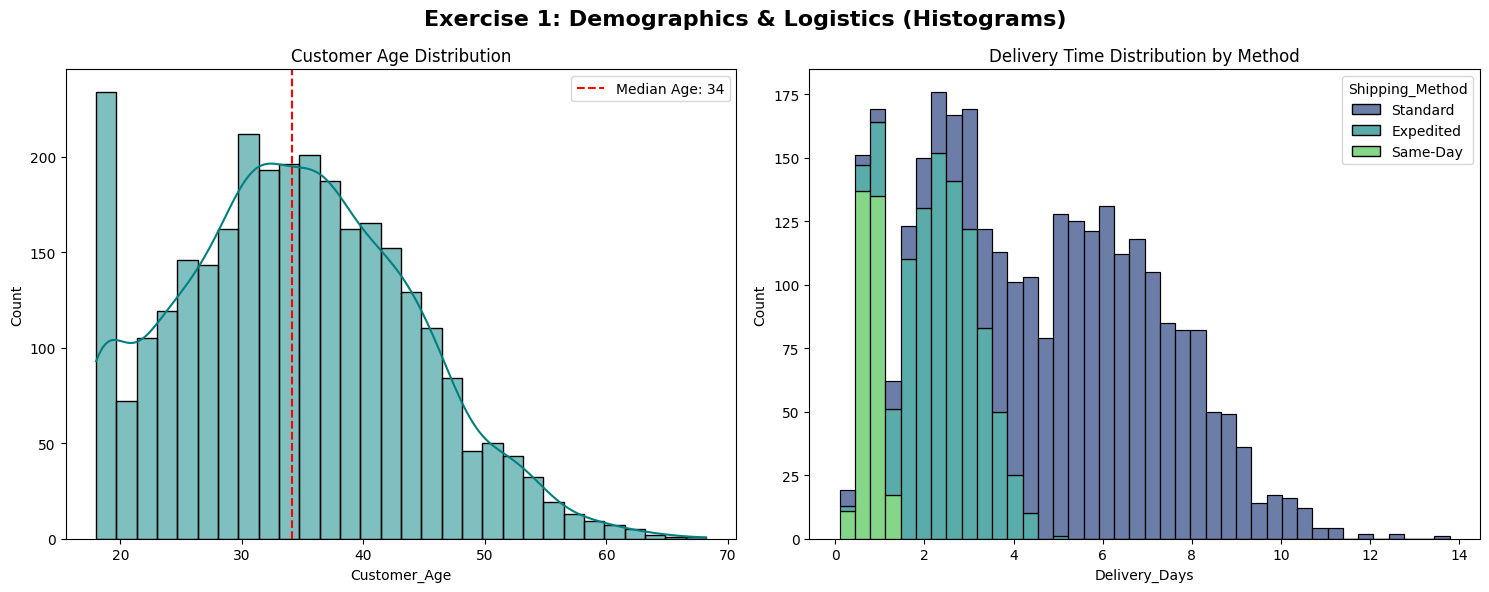

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data (simulating starting fresh)
df = pd.read_csv('globaltech_master_data.csv')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Exercise 1: Demographics & Logistics (Histograms)', fontsize=16, fontweight='bold')

# 1. Customer Age Distribution
sns.histplot(data=df, x='Customer_Age', bins=30, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Customer Age Distribution')
axes[0].axvline(df['Customer_Age'].median(), color='red', linestyle='--', label=f"Median Age: {df['Customer_Age'].median():.0f}")
axes[0].legend()

# 2. Delivery Days by Shipping Method
sns.histplot(data=df, x='Delivery_Days', hue='Shipping_Method', bins=40, multiple="stack", palette='viridis', ax=axes[1])
axes[1].set_title('Delivery Time Distribution by Method')

plt.tight_layout()
plt.show()

Exercise 2 - Scatter Plots (20 Mins)


Business Goal: Analyze the impact of delivery speed on customer satisfaction and evaluate price elasticity.

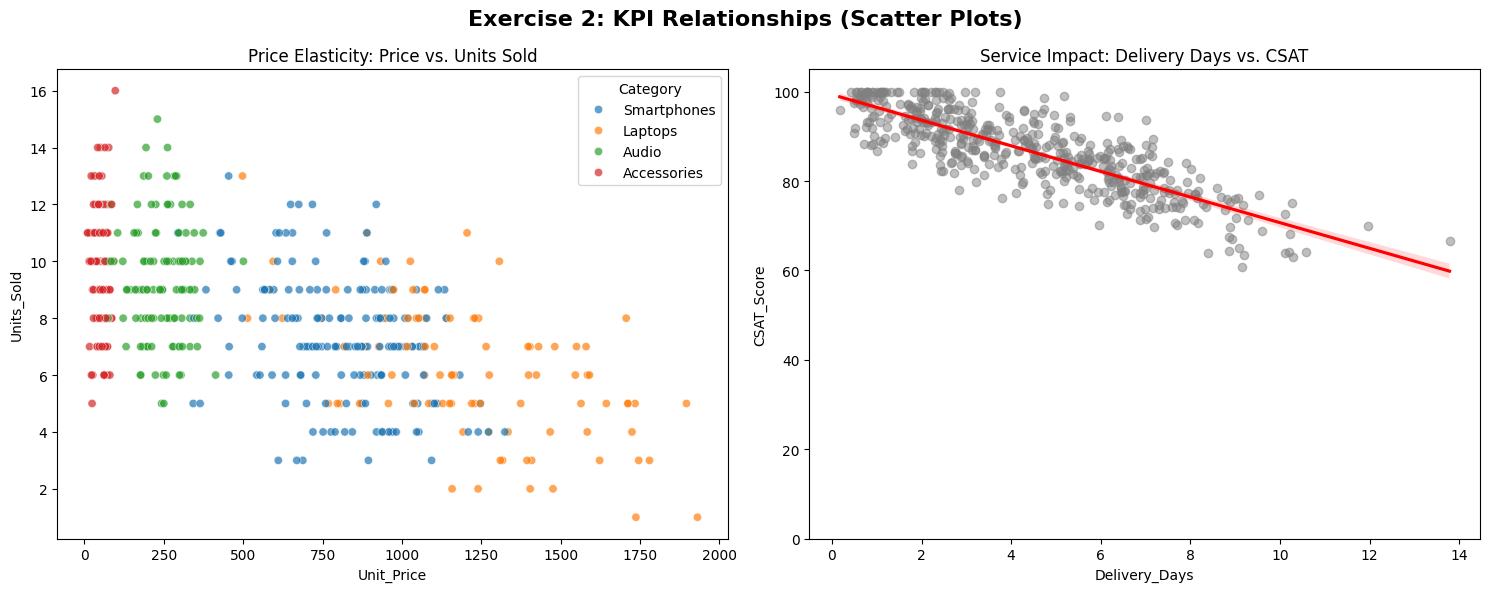

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Exercise 2: KPI Relationships (Scatter Plots)', fontsize=16, fontweight='bold')

# 1. Price Elasticity (Price vs Units Sold)
# Sample 500 rows to prevent overplotting
df_sample = df.sample(500, random_state=42)
sns.scatterplot(data=df_sample, x='Unit_Price', y='Units_Sold', hue='Category', alpha=0.7, ax=axes[0])
axes[0].set_title('Price Elasticity: Price vs. Units Sold')

# 2. SLA Impact (Delivery Time vs CSAT)
sns.regplot(data=df_sample, x='Delivery_Days', y='CSAT_Score', scatter_kws={'alpha':0.5, 'color':'gray'}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Service Impact: Delivery Days vs. CSAT')
axes[1].set_ylim(0, 105) # Keep scores visually grounded

plt.tight_layout()
plt.show()

Exercise 3 - Bar Plots (20 Mins)

Business Goal: Compare total revenue generated across global regions and identify our top-performing product categories.

/tmp/ipykernel_7306/1042293832.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_region, x='Region', y='Revenue', palette='magma', ax=axes[0])
/tmp/ipykernel_7306/1042293832.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=csat_by_cat, x='CSAT_Score', y='Category', palette='crest', ax=axes[1])


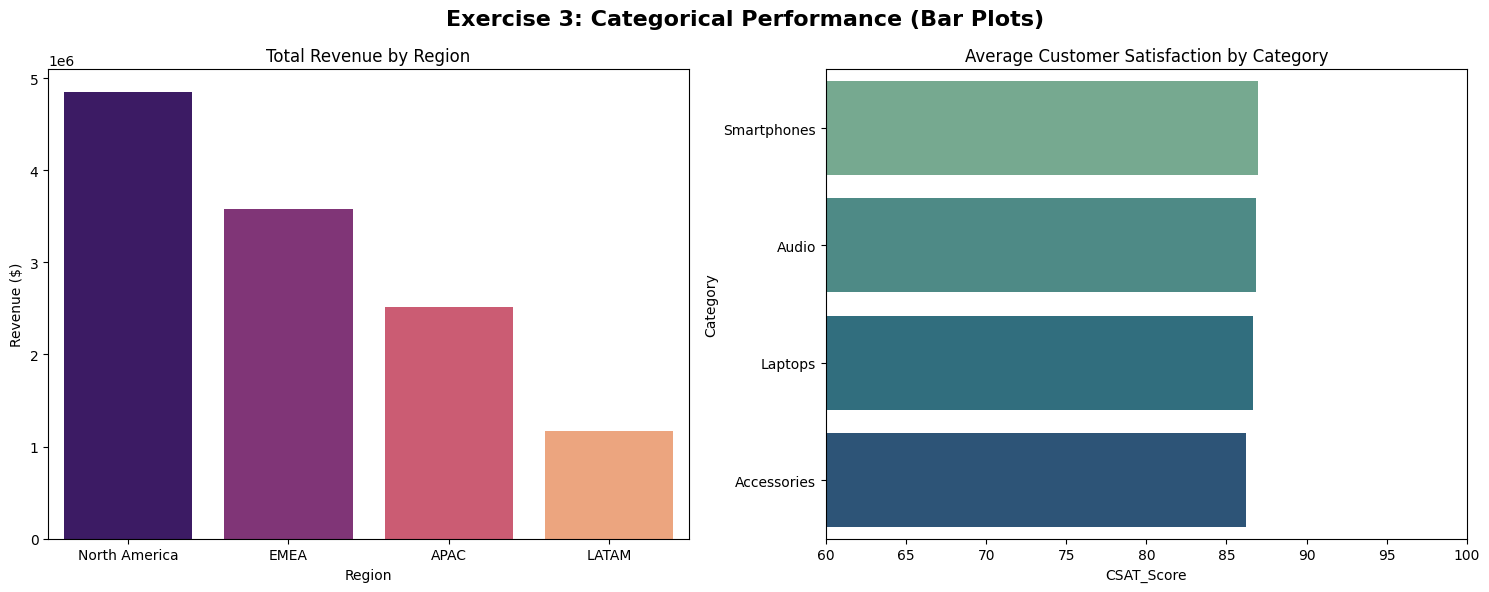

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Exercise 3: Categorical Performance (Bar Plots)', fontsize=16, fontweight='bold')

# 1. Total Revenue by Region
revenue_by_region = df.groupby('Region')['Revenue'].sum().reset_index().sort_values('Revenue', ascending=False)
sns.barplot(data=revenue_by_region, x='Region', y='Revenue', palette='magma', ax=axes[0])
axes[0].set_title('Total Revenue by Region')
axes[0].set_ylabel('Revenue ($)')

# 2. Average CSAT by Category
csat_by_cat = df.groupby('Category')['CSAT_Score'].mean().reset_index().sort_values('CSAT_Score', ascending=False)
sns.barplot(data=csat_by_cat, x='CSAT_Score', y='Category', palette='crest', ax=axes[1])
axes[1].set_title('Average Customer Satisfaction by Category')
axes[1].set_xlim(60, 100) # Zoom in to see the differences clearly

plt.tight_layout()
plt.show()

Exercise 4 - Box Plots (20 Mins)


Business Goal: Spot massive outliers in order values and analyze the reliability (variance) of our shipping methods.

/tmp/ipykernel_7306/2877243944.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Revenue', palette='Set2', showfliers=True, ax=axes[0])


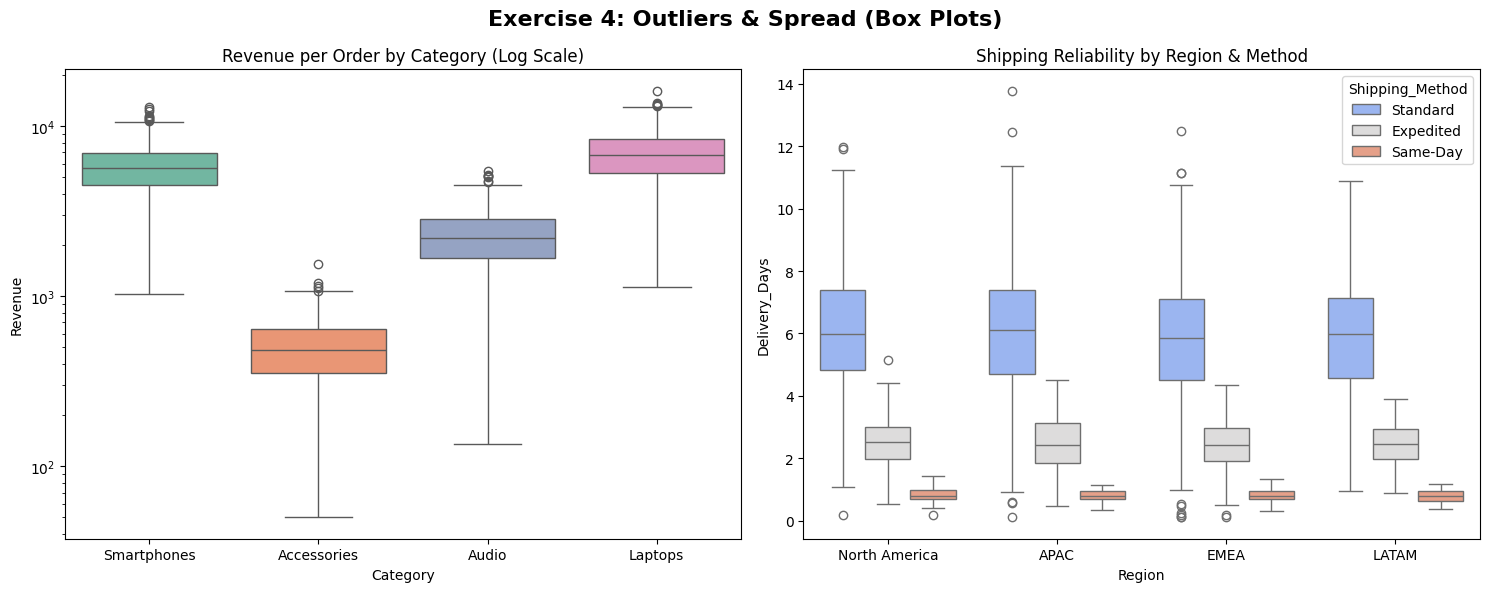

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Exercise 4: Outliers & Spread (Box Plots)', fontsize=16, fontweight='bold')

# 1. Order Revenue Spread by Category
sns.boxplot(data=df, x='Category', y='Revenue', palette='Set2', showfliers=True, ax=axes[0])
axes[0].set_title('Revenue per Order by Category (Log Scale)')
axes[0].set_yscale('log') # Log scale handles the massive difference between laptops and accessories

# 2. Shipping Reliability (Delivery Days by Region)
sns.boxplot(data=df, x='Region', y='Delivery_Days', hue='Shipping_Method', palette='coolwarm', ax=axes[1])
axes[1].set_title('Shipping Reliability by Region & Method')

plt.tight_layout()
plt.show()

Exercise 5 - Line Plots & Curves (20 Mins)


Business Goal: Track our monthly revenue growth over the two-year period and compare it to an idealized growth curve.

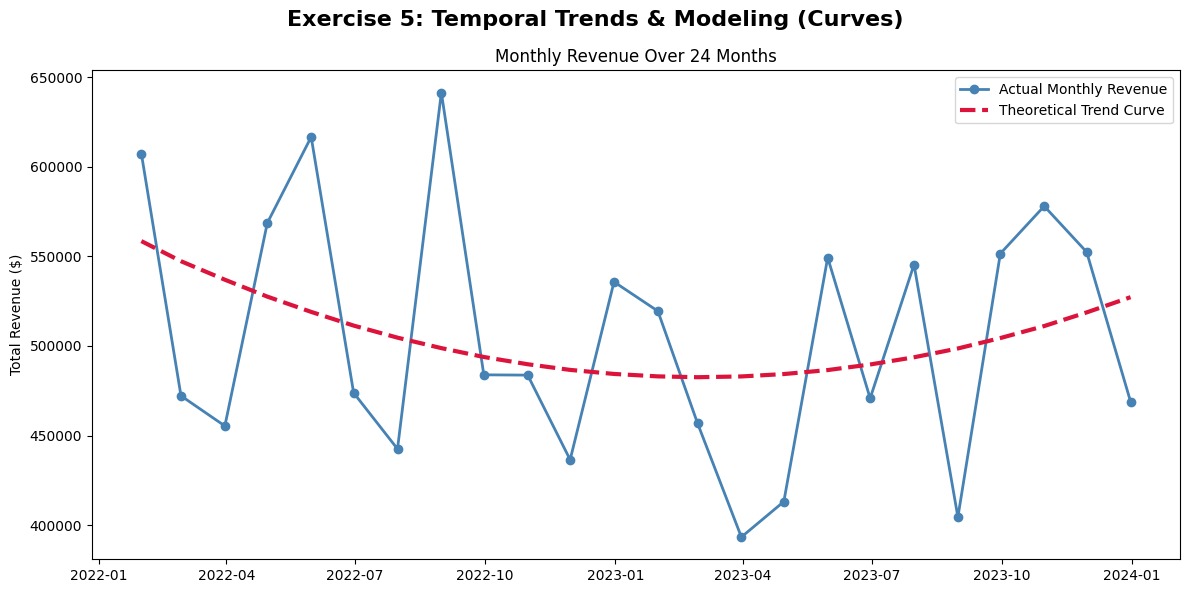

In [10]:
# Ensure Order_Date is a datetime object
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Aggregate revenue by month
monthly_rev = df.set_index('Order_Date').resample('ME')['Revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Exercise 5: Temporal Trends & Modeling (Curves)', fontsize=16, fontweight='bold')

# 1. Actual Monthly Revenue (Line Plot)
ax.plot(monthly_rev['Order_Date'], monthly_rev['Revenue'], marker='o', color='steelblue', linewidth=2, label='Actual Monthly Revenue')

# 2. Theoretical Trend Curve (Polynomial Fit)
# Convert dates to numerical values for curve fitting
x_num = np.arange(len(monthly_rev))
y_rev = monthly_rev['Revenue'].values
# Fit a 2nd-degree polynomial (quadratic curve) to show the general trend
z = np.polyfit(x_num, y_rev, 2)
p = np.poly1d(z)

# Plot the smooth theoretical curve over the actual data
ax.plot(monthly_rev['Order_Date'], p(x_num), color='crimson', linestyle='--', linewidth=3, label='Theoretical Trend Curve')

ax.set_title('Monthly Revenue Over 24 Months')
ax.set_ylabel('Total Revenue ($)')
ax.legend()

plt.tight_layout()
plt.show()